# S8 — Cross-section panels: every variable, every scenario

Vertical cross-section at fixed `j`, for the 2024-03-19 1800 UTC single-cycle DA.

**Figure 1** — one scenario. Rows `Truth / Prior / AOEI / TEnKF Nt=1 / TEnKF Nt=2`,
columns `qg qr qs T P u v w DBZ`.
**Figure 2** — one variable, the same 5 rows, one column per scenario (6 runs).
**Figure 3** — the increments (`analysis − prior`) for the same scenario as Figure 1.

## Where each row comes from

Nothing is recomputed: every panel is a direct read. The forward operator `H` is never
re-evaluated and the 10.6 GB `state_ensemble` is never opened.

| Row | File | Key |
|---|---|---|
| Truth (state) | ref | `truth[:, j0, :, v]` |
| Truth (dBZ) | ref | `truth_hx[:, j0, :]` |
| Prior (state) | ref | `xf_mean[:, j0, :, v]` |
| Prior (dBZ) | any combo | `hxf_mean_field[:, j0, :]` |
| Analysis (state) | ref + combo | `truth + bias_a_field`  (`bias_a_field = xa_mean − truth`) |
| Analysis (dBZ) | combo | `hxa_mean_field[:, j0, :]` |

`hxf_mean_field = mean_m H(xf_m)` and `hxa_mean_field = mean_m H(xa_m)` — both are ensemble
means *in observation space*, so the dBZ column is internally consistent with `truth_hx = H(truth)`.
All six runs share `dbz_min=0.0`, `obs_error_var=5.0`, `stride=2`, so dBZ is comparable across them.

## Four traps this notebook defends against

1. **The `loc=0.1` analysis is a comb, not a field.** Only observed cells are updated. On a given
   `j` only even `i`-columns carry an observation (`stride=2`), so ~30% of the slice has a nonzero
   `w` increment versus ~83% at `loc=2.0`. We render with `pcolormesh` (one quad per grid cell)
   rather than `contourf`, which would interpolate across the untouched columns and invent a smooth
   field. That artifact is what made the original comparison figure misleading.

2. **`T` and `P` are stratification-dominated.** The truth's level mean spans 78 K and 75,700 Pa
   while the analysis increment is ~2 K and ~70 Pa — ratios of 43× and 1080×. Plotted raw (as
   configured) those two columns are flat horizontal stripes. **Figure 3 is where `T` and `P`
   become readable.** Set `ANOM_VARS = ('T','P','u','v')` in the config cell to subtract the truth's
   level mean instead; the same constant is removed from every row and every scenario, so all
   differences are preserved exactly.

3. **The two sweeps do not share an observation set.** QC is `ens_hx.var > 0`, which depends on
   `Ne`: the Ne=40 sweep has 693,783 points, the Ne=59 sweep has 750,931 (8.2% more). Left alone,
   the Ne=59 sweep column would show a denser comb than its multi_obs twin for a reason that has
   nothing to do with the DA. `RESTRICT_TO_SHARED_MASK = True` intersects both sweeps with the
   shared 693,783-point set.

4. **"Severe points" has two different definitions.** `S7_SignFlip_Mechanism.ipynb` counts them
   *at observed cells only* (`125` for `loc=2.0, Ne=40`). Counted over **all** cells — including
   every cell that localization reaches — the same run has `710`. This notebook reports both, and
   never mixes them.

## Where the pathology actually lives

The classic storm cross-section `j=272` contains only **2** severe points out of 710. The
`SEVERE SCAN` cell finds the slice and window that actually show the failure, and (with
`AUTO_TARGET = True`) retargets the figures onto it. Set `AUTO_TARGET = False` to return to the
`j=272` storm slice used by `SingleObs_CrossSection.ipynb`.

Mechanism and closed-form validation: `S7_SignFlip_Mechanism.ipynb`.

In [1]:
import os, glob, yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

REPO   = '/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation'
D      = os.path.join(REPO, 'data')
SUBSET = f'{D}/3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz'

VI   = {'qg': 0, 'qr': 1, 'qs': 2, 'T': 3, 'P': 4, 'u': 5, 'v': 6, 'w': 7}
VARS = ['qg', 'qr', 'qs', 'T', 'P', 'u', 'v', 'w']
COLS = VARS + ['DBZ']
NX, NY, NZ = 558, 898, 11
NOBS_SHARED = 693783

# per-variable PHYSICAL tolerances. An absolute atol mis-scales across variables (P ~ 9e4 Pa vs
# w ~ 1 m/s) and a max over half a million points is dominated by single outliers.
TOL = dict(qg=1e-6, qr=1e-6, qs=1e-6, T=1e-2, P=1.0, u=1e-3, v=1e-3, w=1e-3)

UNITS = {'qg': 'g kg$^{-1}$', 'qr': 'g kg$^{-1}$', 'qs': 'g kg$^{-1}$', 'T': 'K', 'P': 'Pa',
         'u': 'm s$^{-1}$', 'v': 'm s$^{-1}$', 'w': 'm s$^{-1}$', 'DBZ': 'dBZ'}
RAW_UNITS = dict(qg='kg/kg', qr='kg/kg', qs='kg/kg', T='K', P='Pa',
                 u='m/s', v='m/s', w='m/s', DBZ='dBZ')

# ---- cross-section geometry ------------------------------------------------
J0     = 272     # fixed j.  272 = the storm slice used by SingleObs_CrossSection.ipynb
K_C    = 7       # level used to auto-pick the reference column (z = 6 km)
I_C    = -1      # -1 -> argmax prior DBZ along (J0, K_C);  >= 0 -> pin the column
WIN_KM = 40.0    # +/- horizontal window around the reference column

# ---- flags -----------------------------------------------------------------
AUTO_TARGET = True          # retarget (J0, I_C) onto the window with the most severe points.
                            # False -> keep the j=272 storm slice (which holds only 2 of 710).
SCAN_METHOD = ('TEnKF', 1)  # method whose severe points drive the retargeting

RENDER      = 'mesh'        # 'mesh' = pcolormesh, one quad per grid cell | 'contour'
SHOW_OBS    = False         # dot the cells that carried an assimilated observation
MARK_SEVERE = True          # circle (truth_w > 1) & (prior_w > 0) & (analysis_w < -1)
HYDRO_GKG   = True          # display qg/qr/qs in g/kg  (a unit change, not a reference removal)
ANOM_VARS   = ()            # e.g. ('T','P','u','v') -> subtract the truth's level mean
RESTRICT_TO_SHARED_MASK = True

SCEN_MAIN = 'MO_L2.0_Ne40'  # scenario for Figures 1 and 3 (the run that started this)
VAR_CMP   = 'w'             # variable for Figure 2

# ---- the six scenarios -----------------------------------------------------
# NOTE: WS_multiobs_1800 contains TWO ref files -- ref_Ne040 (693,783 obs, correct) and an
# orphaned ref_Ne059 (3,007,528 obs, stride=1, from the May run that died of stack overflow).
# Refs are therefore built by exact filename, never globbed.
SCEN = {
    'SW_L0.1_Ne40': dict(kind='sw', dir='WS_diag1800_SW_L0.1_Ne40',    loc=0.1, ne=40, twin='MO_L0.1_Ne40'),
    'MO_L0.1_Ne40': dict(kind='mo', dir='WS_diag1800_MO_L0.1_Ne40',    loc=0.1, ne=40),
    'SW_L0.1_Ne59': dict(kind='sw', dir='WS_singleobs_xsec_1800_GUES', loc=0.1, ne=59, twin='MO_L0.1_Ne59'),
    'MO_L0.1_Ne59': dict(kind='mo', dir='WS_diag1800_MO_L0.1_Ne59',    loc=0.1, ne=59),
    'MO_L2.0_Ne40': dict(kind='mo', dir='WS_multiobs_1800',            loc=2.0, ne=40),
    'MO_L2.0_Ne59': dict(kind='mo', dir='WS_diag1800_MO_L2.0_Ne59',    loc=2.0, ne=59),
}
for _n, _s in SCEN.items():
    _s['tag'] = _s['dir']
    _s['nes'] = f"{_s['ne']:03d}"
    _rd = SCEN[_s['twin']]['dir'] if _s['kind'] == 'sw' else _s['dir']
    _s['ref'] = f"{D}/{_rd}/{_rd}_multi_obs_ref_Ne{_s['nes']}_tm00.npz"

SCEN_MO = [n for n, s in SCEN.items() if s['kind'] == 'mo']
SCEN_SW = [n for n, s in SCEN.items() if s['kind'] == 'sw']

ANALYSES     = [('AOEI', ('AOEI', 1)), ('TEnKF Nt=1', ('TEnKF', 1)), ('TEnKF Nt=2', ('TEnKF', 2))]
ANALYSIS_KEY = [k for _, k in ANALYSES]
ROW_LABELS   = ['Truth', 'Prior'] + [l for l, _ in ANALYSES]


def combo_path(name, method, nt):
    """Analysis npz. A sweep scenario borrows its twin's combo (only for hxf_mean_field)."""
    s = SCEN[name]
    if s['kind'] == 'sw':
        s = SCEN[s['twin']]
    L = f"{s['loc']:.1f}"
    return (f"{D}/{s['dir']}/{s['tag']}_multi_obs_{method}_Nt{nt:02d}_as1.0_"
            f"Lx{L}Ly{L}Lz{L}_Ne{s['nes']}_tm00.npz")


def sweep_path(name):
    s = SCEN[name]
    return f"{D}/{s['dir']}/{s['tag']}_sweep_Ne{s['nes']}_tm00.npz"


missing = [p for n in SCEN for p in
           ([SCEN[n]['ref']] + ([sweep_path(n)] if SCEN[n]['kind'] == 'sw' else
                                [combo_path(n, m, t) for m, t in ANALYSIS_KEY]))
           if not os.path.exists(p)]
assert not missing, 'missing files:\n  ' + '\n  '.join(missing)
print(f'{len(SCEN)} scenarios, all files present')
print(f'rows: {ROW_LABELS}')
print(f'cols: {COLS}')

6 scenarios, all files present
rows: ['Truth', 'Prior', 'AOEI', 'TEnKF Nt=1', 'TEnKF Nt=2']
cols: ['qg', 'qr', 'qs', 'T', 'P', 'u', 'v', 'w', 'DBZ']


In [2]:
# ---------------------------------------------------------------------------
# Loaders.  The npz members are DEFLATE-compressed, so a key cannot be memory-mapped or
# sliced on disk: reading any 4-D field costs a full 176 MB decompress (~0.9 s).  We therefore
# decompress once per (path, key, j) and cache only the j-slice, which is 393 kB.
# The cache key carries J0 because AUTO_TARGET may change it after this cell has run.
# ---------------------------------------------------------------------------
_SL, _SW = {}, {}


def sl(path, key):
    """The j = J0 slice of `key`.  (nx, nz, nvar) for 4-D keys, (nx, nz) for 3-D."""
    ck = (path, key, J0)
    if ck not in _SL:
        with np.load(path) as f:
            _SL[ck] = np.asarray(f[key][:, J0], dtype=np.float64)
    return _SL[ck]


def sweep_slice(name):
    """Per-point sweep rows on j = J0, grouped by (method, ntemp).

    Sweeps store no fields, only rows.  QC (`ens_hx.var > 0`) depends on Ne, so the Ne=59 sweep
    carries 750,931 points against the shared 693,783 -- intersect, or its comb looks denser than
    its multi_obs twin for a reason unrelated to the DA.
    """
    ck = (sweep_path(name), J0, RESTRICT_TO_SHARED_MASK)
    if ck in _SW:
        return _SW[ck]
    with np.load(ck[0], allow_pickle=True) as f:
        meth = f['method'].astype(str)
        nt = f['ntemp'].astype(int)
        i_, j_, k_ = f['i'].astype(int), f['j'].astype(int), f['k'].astype(int)
        onj = j_ == J0
        keep = onj.copy()
        if RESTRICT_TO_SHARED_MASK:
            keep[onj] = OBS3[i_[onj], J0, k_[onj]]
        a = {v: f[f'mean_a_point_{v}'][keep] for v in VARS}
        b = {v: f[f'mean_f_point_{v}'][keep] for v in VARS}
        hxa, hxf = f['hxa_mean_obs'][keep], f['hxf_mean_obs'][keep]
        mm, nn, ii, kk = meth[keep], nt[keep], i_[keep], k_[keep]
        n_drop = int(onj.sum() - keep.sum())
    out = {'n_on_j': int(onj.sum()), 'n_drop': n_drop}
    for m, n in ANALYSIS_KEY:
        s = (mm == m) & (nn == n)
        out[(m, n)] = dict(i=ii[s], k=kk[s], hxa=hxa[s], hxf=hxf[s],
                           a={v: a[v][s] for v in VARS}, f={v: b[v][s] for v in VARS})
    _SW[ck] = out
    return out


def _pack(state, dbz):
    d = {v: state[..., VI[v]] for v in VARS}
    d['DBZ'] = dbz
    return d


def rows(name):
    """{row_label: {var: (nx, nz)}} for one scenario, in RAW units."""
    s = SCEN[name]
    truth = sl(s['ref'], 'truth')
    xfm   = sl(s['ref'], 'xf_mean')
    thx   = sl(s['ref'], 'truth_hx')
    hxf   = sl(combo_path(name, 'TEnKF', 1), 'hxf_mean_field')

    out = {'Truth': _pack(truth, thx), 'Prior': _pack(xfm, hxf)}
    if s['kind'] == 'mo':
        for lab, (m, n) in ANALYSES:
            p = combo_path(name, m, n)
            # bias_a_field = xa_mean - truth  (metrics.py:286), so xa_mean = truth + bias_a_field
            out[lab] = _pack(truth + sl(p, 'bias_a_field'), sl(p, 'hxa_mean_field'))
    else:
        sw = sweep_slice(name)
        for lab, (m, n) in ANALYSES:
            r = sw[(m, n)]
            st, dz = xfm.copy(), hxf.copy()      # unobserved cells keep the prior
            for v in VARS:
                st[r['i'], r['k'], VI[v]] = r['a'][v]
            dz[r['i'], r['k']] = r['hxa']
            out[lab] = _pack(st, dz)
    return out


_LEVM = {}


def levmean(v):
    """Truth's domain-wide mean at each level.  Only used when ANOM_VARS is non-empty."""
    if not _LEVM:
        with np.load(SCEN['MO_L0.1_Ne40']['ref']) as f:
            t = f['truth']
            for vv in VARS:
                _LEVM[vv] = np.nanmean(t[..., VI[vv]], axis=(0, 1))
    return _LEVM[v]


def disp(v, F):
    """Raw field -> displayed field (anomaly and/or unit change)."""
    G = F
    if v in ANOM_VARS:
        G = G - levmean(v)[None, :]
    if HYDRO_GKG and v in ('qg', 'qr', 'qs'):
        G = G * 1e3
    return G


def sev_mask(R, lab):
    """S7 pathology on the slice: truth updraft, prior updraft, analysis downdraft."""
    with np.errstate(invalid='ignore'):
        return (R['Truth']['w'] > 1.0) & (R['Prior']['w'] > 0.0) & (R[lab]['w'] < -1.0)


print('loaders ready')

loaders ready


In [3]:
# ---- grid + the shared observation mask (both independent of J0) ------------
# pos_km is one lazily-loaded member of the prepared npz -- state_ensemble (10.6 GB) is not read.
with np.load(SUBSET) as _sub:
    POS = _sub['pos_km']                        # (nx, ny, nz, 3) = (x_km, y_km, z_km), float32, 66 MB
DX = float(np.median(np.diff(POS[:, 0, 0, 0].astype(np.float64))))
Z_LEVELS = np.unique(np.round(POS[0, 0, :, 2], 3))

with np.load(SCEN['MO_L0.1_Ne40']['ref']) as _f:
    _ix, _iy, _iz = _f['ix'], _f['iy'], _f['iz']
assert len(_ix) == NOBS_SHARED, f'shared ref has {len(_ix)} obs, expected {NOBS_SHARED}'
OBS3 = np.zeros((NX, NY, NZ), bool)             # the 693,783-point shared observation set
OBS3[_ix, _iy, _iz] = True

print(f'z levels [km] : {Z_LEVELS}')
print(f'dx            : {DX:.3f} km   (stride 2 -> an observation every {2*DX:.2f} km)')
print(f'shared obs set: {len(_ix):,} points  ({OBS3.mean():.1%} of the {NX}x{NY}x{NZ} domain)')

z levels [km] : [ 0.25  0.5   1.    2.    3.    4.    5.    6.    8.   10.   12.  ]
dx            : 1.983 km   (stride 2 -> an observation every 3.97 km)
shared obs set: 693,783 points  (12.6% of the 558x898x11 domain)


In [4]:
# ===========================================================================
# SEVERE SCAN -- where does the analysis actually break?
#
# "Severe" = truth has an updraft (w > 1), the prior has an updraft (w > 0), and the analysis
# produces a downdraft (w < -1).  S7 counts these AT OBSERVED CELLS ONLY.  Counted over all
# cells -- every cell localization reaches -- the numbers are ~5.7x larger.  Both are reported;
# they must never be mixed.
# ===========================================================================
_W3 = {}


def _w3(path, key):
    ck = (path, key)
    if ck not in _W3:
        with np.load(path) as f:
            a = f[key]
            _W3[ck] = np.asarray(a[..., VI['w']] if a.ndim == 4 else a, dtype=np.float64)
    return _W3[ck]


def severe3d(name, m, nt):
    s = SCEN[name]
    tw, fw = _w3(s['ref'], 'truth'), _w3(s['ref'], 'xf_mean')
    aw = tw + _w3(combo_path(name, m, nt), 'bias_a_field')     # xa_mean = truth + bias_a_field
    with np.errstate(invalid='ignore'):
        return (tw > 1.0) & (fw > 0.0) & (aw < -1.0)


print(f'severe points in {SCEN_MAIN}  (loc={SCEN[SCEN_MAIN]["loc"]} km, Ne={SCEN[SCEN_MAIN]["ne"]})\n')
print(f'   {"method":12s} {"all cells":>10s} {"at obs pts":>12s}    <- S7 quotes the obs-pt column')
_masks = {}
for _m, _nt in [('AOEI', 1), ('TEnKF', 1), ('TEnKF', 2), ('TEnKF', 3)]:
    S = severe3d(SCEN_MAIN, _m, _nt)
    _masks[(_m, _nt)] = S
    print(f'   {_m + " Nt=" + str(_nt):12s} {int(np.nansum(S)):10d} {int(np.nansum(S & OBS3)):12d}')
print('\n   AOEI suppresses the flip (it inflates R to ~1487 against R0=5, shrinking the gain ~26x).')
print('   Tempering aggravates it, with an odd/even sawtooth across ntemp.')

S = _masks[SCAN_METHOD]
_perj = S.sum(axis=(0, 2))
print(f'\n   the classic storm slice j=272 holds {int(_perj[272])} of {int(S.sum())} severe points '
      f'-> it cannot show the failure')

# best +/- WIN_KM window, over every (j, i_centre)
HALF = int(round(WIN_KM / DX))
_cnt = S.sum(axis=2)                                    # (nx, ny)
_cs = np.vstack([np.zeros((1, NY), int), np.cumsum(_cnt, axis=0)])
_Wn = np.stack([_cs[min(NX, ic + HALF + 1)] - _cs[max(0, ic - HALF)] for ic in range(NX)])
_order = np.argsort(_Wn.ravel())[::-1]

print(f'\n   best +/-{WIN_KM:.0f} km windows for {SCAN_METHOD[0]} Nt={SCAN_METHOD[1]}:')
_seen, _best = set(), None
for _f in _order:
    ic, j = np.unravel_index(_f, _Wn.shape)
    if j in _seen:
        continue
    _seen.add(int(j))
    if _best is None:
        _best = (int(j), int(ic))
    print(f'      J0={j:4d}  I_C={ic:4d}  -> {int(_Wn[ic, j]):3d} severe pts in window '
          f'(whole j-slice: {int(_perj[j])})')
    if len(_seen) >= 5:
        break

if AUTO_TARGET:
    J0, I_C = _best
    print(f'\n   AUTO_TARGET=True -> retargeted to J0={J0}, I_C={I_C}.')
    print(f'   Set AUTO_TARGET=False for the j=272 storm slice of SingleObs_CrossSection.ipynb.')
else:
    print(f'\n   AUTO_TARGET=False -> keeping J0={J0}, I_C={I_C} (expect few or no green circles).')

del _W3, _masks, S

severe points in MO_L2.0_Ne40  (loc=2.0 km, Ne=40)

   method        all cells   at obs pts    <- S7 quotes the obs-pt column
   AOEI Nt=1           177           19
   TEnKF Nt=1          710          125
   TEnKF Nt=2         1536          357
   TEnKF Nt=3         1118          252

   AOEI suppresses the flip (it inflates R to ~1487 against R0=5, shrinking the gain ~26x).
   Tempering aggravates it, with an odd/even sawtooth across ntemp.

   the classic storm slice j=272 holds 2 of 710 severe points -> it cannot show the failure

   best +/-40 km windows for TEnKF Nt=1:
      J0= 698  I_C= 219  ->  13 severe pts in window (whole j-slice: 13)
      J0= 290  I_C= 371  ->  13 severe pts in window (whole j-slice: 13)
      J0= 327  I_C= 351  ->  10 severe pts in window (whole j-slice: 10)
      J0= 307  I_C= 354  ->   9 severe pts in window (whole j-slice: 16)
      J0= 867  I_C= 157  ->   9 severe pts in window (whole j-slice: 9)

   AUTO_TARGET=True -> retargeted to J0=698, I_C=219.

In [5]:
# ---- geometry for the (possibly retargeted) slice ---------------------------
X = POS[:, J0, :, 0].astype(np.float64)         # (nx, nz)
Z = POS[:, J0, :, 2].astype(np.float64)
OBSJ = OBS3[:, J0, :]                           # observed cells on this slice

_hxf_main = sl(combo_path(SCEN_MAIN, 'TEnKF', 1), 'hxf_mean_field')
i_c = int(np.nanargmax(_hxf_main[:, K_C])) if I_C < 0 else int(I_C)
x0, z0 = X[i_c, K_C], Z[i_c, K_C]
Xd = X - x0

col_ok = np.abs(Xd[:, 0]) <= WIN_KM
xi = np.flatnonzero(col_ok)
cut = lambda F: np.asarray(F)[xi, :]
Xw, Zw = cut(Xd), cut(Z)

print(f'slice            : j={J0}   ({"auto-targeted" if AUTO_TARGET else "pinned"})')
print(f'reference column : i={i_c}, k={K_C}  ->  x={x0:.1f} km, z={z0:.2f} km')
print(f'                   prior DBZ there = {_hxf_main[i_c, K_C]:.1f} dBZ  '
      f'({"argmax of prior DBZ" if I_C < 0 else "pinned"})')

# The star is only a visual anchor; it need not be an observed cell.  stride=2 observes even i.
_obs_here = bool(OBSJ[i_c, K_C])
print(f'                   observed? {"YES" if _obs_here else "NO   <- stride=2 observes only even i"}')
if not _obs_here:
    if OBSJ[:, K_C].any():
        _e = int(np.nanargmax(np.where(OBSJ[:, K_C], _hxf_main[:, K_C], -np.inf)))
        print(f'                   strongest observed column on (j={J0}, k={K_C}): i={_e}, '
              f'prior DBZ={_hxf_main[_e, K_C]:.1f}  (all a sweep can see)')
    else:
        print(f'                   no cell at k={K_C} on this slice passed QC -- a sweep sees nothing here')

print(f'window +/-{WIN_KM:.0f} km  : {len(xi)} i-columns [i={xi[0]}..{xi[-1]}], '
      f'{int(OBSJ[xi].any(axis=1).sum())} of them carry an observation')
print(f'panel grid       : {len(xi)} x {NZ} cells  '
      f'({int(OBSJ[xi].sum())} of {OBSJ[xi].size} cells observed = {OBSJ[xi].mean():.0%})')

slice            : j=698   (auto-targeted)
reference column : i=219, k=7  ->  x=490.5 km, z=6.00 km
                   prior DBZ there = 4.8 dBZ  (pinned)
                   observed? NO   <- stride=2 observes only even i
                   strongest observed column on (j=698, k=7): i=250, prior DBZ=15.4  (all a sweep can see)
window +/-40 km  : 43 i-columns [i=198..240], 22 of them carry an observation
panel grid       : 43 x 11 cells  (242 of 473 cells observed = 51%)


In [6]:
# ===========================================================================
# Verification.  Everything below the plots depends on these; fail loudly first.
# ===========================================================================
ok = True


def check(label, cond, detail=''):
    global ok
    ok &= bool(cond)
    print(f"  [{'PASS' if cond else 'FAIL'}] {label}{('  ' + detail) if detail else ''}")


print('--- 1. reconstruction identity  xf_mean == truth + bias_f_field  (per-variable TOL) ---')
for n in SCEN_MO:
    tr, xf = sl(SCEN[n]['ref'], 'truth'), sl(SCEN[n]['ref'], 'xf_mean')
    bf = sl(combo_path(n, 'TEnKF', 1), 'bias_f_field')
    nbad = sum(int(np.nansum(np.abs((tr + bf)[..., VI[v]] - xf[..., VI[v]]) > TOL[v])) for v in VARS)
    check(f'{n:14s}', nbad == 0, f'rows over tol: {nbad}')

print('\n--- 2. truth is bitwise identical across all four multi_obs refs ---')
_t0 = sl(SCEN['MO_L0.1_Ne40']['ref'], 'truth')
for n in SCEN_MO[1:]:
    check(f'{n:14s}', np.array_equal(sl(SCEN[n]['ref'], 'truth'), _t0, equal_nan=True))

print('\n--- 3. xf_mean identical within each Ne group, different across groups ---')
_x40 = sl(SCEN['MO_L0.1_Ne40']['ref'], 'xf_mean')
_x59 = sl(SCEN['MO_L0.1_Ne59']['ref'], 'xf_mean')
check('Ne=40 pair identical', np.array_equal(_x40, sl(SCEN['MO_L2.0_Ne40']['ref'], 'xf_mean'), equal_nan=True))
check('Ne=59 pair identical', np.array_equal(_x59, sl(SCEN['MO_L2.0_Ne59']['ref'], 'xf_mean'), equal_nan=True))
check('Ne=40 vs Ne=59 differ', not np.array_equal(_x40, _x59, equal_nan=True))

print('\n--- 4. config homogeneity (otherwise the DBZ column is not comparable) ---')
_seen = {}
for n, s in SCEN.items():
    cfg = yaml.safe_load(open(glob.glob(f"{D}/{s['dir']}/*_config.yaml")[0]))
    _seen[n] = (cfg['qc']['dbz_min'], cfg['qc']['clamp_obs'], cfg['obs']['add_noise'],
                cfg['obs']['obs_error_var'], cfg['sweep']['stride'])
check('dbz_min / clamp_obs / add_noise / obs_error_var / stride agree',
      len(set(_seen.values())) == 1, str(next(iter(_seen.values()))))

print('\n--- 5. no orphan ref adopted (the stride-1 file has 3,007,528 obs) ---')
for n, s in SCEN.items():
    with np.load(s['ref']) as f:
        nobs = len(f['ix'])
    check(f'{n:14s}', nobs == NOBS_SHARED, f'nobs={nobs:,}')

print('\n--- 6. sweep == multi_obs at loc=0.1 on the shared mask (k >= 2) ---')
# At loc_z = 0.1 the cutoff is dist <= (2*sqrt(10/3))^2 = 13.333 and (0.25/0.1)^2 = 6.25 < 13.333,
# so a k=0 cell also sees the k=1 obs while the sweep passes only one.  k <= 1 MUST disagree.
for n in SCEN_SW:
    sw, twin = sweep_slice(n), SCEN[n]['twin']
    tr, xfm = sl(SCEN[twin]['ref'], 'truth'), sl(SCEN[twin]['ref'], 'xf_mean')
    for lab, (m, t) in ANALYSES:
        r = sw[(m, t)]
        mo = tr + sl(combo_path(twin, m, t), 'bias_a_field')
        hi = r['k'] >= 2
        nb = sum(int(np.nansum(np.abs(r['a'][v][hi] - mo[r['i'][hi], r['k'][hi], VI[v]]) > TOL[v]))
                 for v in VARS)
        nlo = int(np.nansum(np.abs(r['a']['w'][~hi] - mo[r['i'][~hi], r['k'][~hi], VI['w']]) > TOL['w']))
        check(f'{n:14s} {lab:11s}', nb == 0,
              f'k>=2 rows={int(hi.sum())} over-tol={nb} | k<=1 expected-disagree={nlo}')
    r1 = sw[('TEnKF', 1)]
    check(f'{n:14s} prior at obs pts == xf_mean',
          all(int(np.nansum(np.abs(r1['f'][v] - xfm[r1['i'], r1['k'], VI[v]]) > TOL[v])) == 0 for v in VARS))
    print(f'      {n}: {sw["n_on_j"]:,} rows on j={J0}, {sw["n_drop"]:,} dropped by the shared mask')

print('\n--- 7. NaN accounting on the j-slice ---')
# Domain-wide, truth has 4 NaN cells and xf_mean has 127 per variable.  They are NOT created by
# the DA (bias_f_field and bias_a_field carry identical NaN counts); they arrive with the prepared
# subset.  A NaN cell renders as a blank quad, which must not be misread as a zero.
_tot = 0
for n in ['MO_L0.1_Ne40', 'MO_L0.1_Ne59']:
    tr, xf = sl(SCEN[n]['ref'], 'truth'), sl(SCEN[n]['ref'], 'xf_mean')
    nt_, nx_ = int(np.isnan(tr[..., 0]).sum()), int(np.isnan(xf[..., 0]).sum())
    _tot += nt_ + nx_
    print(f'  {n:14s} truth NaN={nt_}  xf_mean NaN={nx_}  cells per var, on j={J0}')
print(f'  => {"no blank quads expected on this slice" if _tot == 0 else "BLANK QUADS = missing data, not zeros"}')

print(f'\n=> ALL CHECKS PASSED: {ok}')
assert ok, 'verification failed -- do not trust the figures below'

--- 1. reconstruction identity  xf_mean == truth + bias_f_field  (per-variable TOL) ---
  [PASS] MO_L0.1_Ne40    rows over tol: 0
  [PASS] MO_L0.1_Ne59    rows over tol: 0
  [PASS] MO_L2.0_Ne40    rows over tol: 0
  [PASS] MO_L2.0_Ne59    rows over tol: 0

--- 2. truth is bitwise identical across all four multi_obs refs ---
  [PASS] MO_L0.1_Ne59  
  [PASS] MO_L2.0_Ne40  
  [PASS] MO_L2.0_Ne59  

--- 3. xf_mean identical within each Ne group, different across groups ---
  [PASS] Ne=40 pair identical
  [PASS] Ne=59 pair identical
  [PASS] Ne=40 vs Ne=59 differ

--- 4. config homogeneity (otherwise the DBZ column is not comparable) ---
  [PASS] dbz_min / clamp_obs / add_noise / obs_error_var / stride agree  (0.0, True, True, 5.0, 2)

--- 5. no orphan ref adopted (the stride-1 file has 3,007,528 obs) ---
  [PASS] SW_L0.1_Ne40    nobs=693,783
  [PASS] MO_L0.1_Ne40    nobs=693,783
  [PASS] SW_L0.1_Ne59    nobs=693,783
  [PASS] MO_L0.1_Ne59    nobs=693,783
  [PASS] MO_L2.0_Ne40    nobs=693,78

In [7]:
# ---- plotting helpers ------------------------------------------------------
DBZ_LVLS = np.arange(0, 66, 5)


def scales(fields, v):
    """Colour scale for one column, shared across every row so the rows are comparable."""
    a = np.concatenate([np.asarray(f).ravel() for f in fields])
    a = a[np.isfinite(a)]
    if a.size == 0:
        return dict(cmap='viridis', vmin=0.0, vmax=1.0)
    if v == 'DBZ':
        return dict(cmap='Spectral_r', norm=BoundaryNorm(DBZ_LVLS, plt.cm.Spectral_r.N))
    if v in ('u', 'v', 'w') or v in ANOM_VARS:
        lim = float(np.percentile(np.abs(a), 99)) or 1.0
        return dict(cmap='RdBu_r', vmin=-lim, vmax=lim)
    if v in ('qg', 'qr', 'qs'):
        # sequential, near-white at 0 so clear air reads as empty; monotone lightness stays legible
        hi = float(np.percentile(a[a > 0], 99.5)) if np.any(a > 0) else 1.0
        return dict(cmap='YlGnBu', vmin=0.0, vmax=hi if hi > 0 else 1.0)
    lo, hi = float(np.percentile(a, 1)), float(np.percentile(a, 99))
    return dict(cmap='viridis', vmin=lo, vmax=hi if hi > lo else lo + 1.0)


def sym_scale(fields):
    """Symmetric diverging scale for increments."""
    a = np.concatenate([np.asarray(f).ravel() for f in fields])
    a = a[np.isfinite(a)]
    lim = float(np.percentile(np.abs(a), 99.5)) if a.size else 1.0
    return dict(cmap='RdBu_r', vmin=-(lim or 1.0), vmax=(lim or 1.0))


def panel(ax, Cw, **kw):
    """One quad per grid cell.  contourf would smooth over the unobserved columns."""
    if RENDER == 'mesh':
        return ax.pcolormesh(Xw, Zw, Cw, shading='nearest', **kw)
    if 'norm' in kw:
        return ax.contourf(Xw, Zw, Cw, levels=DBZ_LVLS, cmap=kw['cmap'], norm=kw['norm'], extend='max')
    return ax.contourf(Xw, Zw, Cw, levels=np.linspace(kw['vmin'], kw['vmax'], 21),
                       cmap=kw['cmap'], extend='both')


def decorate(ax):
    ax.axhline(z0, ls='--', c='k', lw=.6, alpha=.5)
    ax.axvline(0, ls='--', c='k', lw=.6, alpha=.5)
    ax.plot(0, z0, 'k*', ms=8)


def overlay_obs(ax):
    if not SHOW_OBS:
        return
    oi, ok_ = np.where(OBSJ[xi, :])
    ax.scatter(Xw[oi, ok_], Zw[oi, ok_], s=1.2, c='k', alpha=.30, linewidths=0, zorder=5)


def overlay_severe(ax, M):
    """Draw (if enabled) and ALWAYS return the in-window counts: (all cells, at observed cells)."""
    Mw, Ow = cut(M), OBSJ[xi, :]
    mi, mk = np.where(Mw)
    if MARK_SEVERE and mi.size:
        ax.scatter(Xw[mi, mk], Zw[mi, mk], s=42, facecolors='none', edgecolors='lime',
                   linewidths=1.3, zorder=6)
    return int(Mw.sum()), int((Mw & Ow).sum())


print(f"render = {RENDER!r}   hydro units = {'g/kg' if HYDRO_GKG else 'kg/kg'}   "
      f"anomaly vars = {ANOM_VARS or 'none (raw)'}")

render = 'mesh'   hydro units = g/kg   anomaly vars = none (raw)


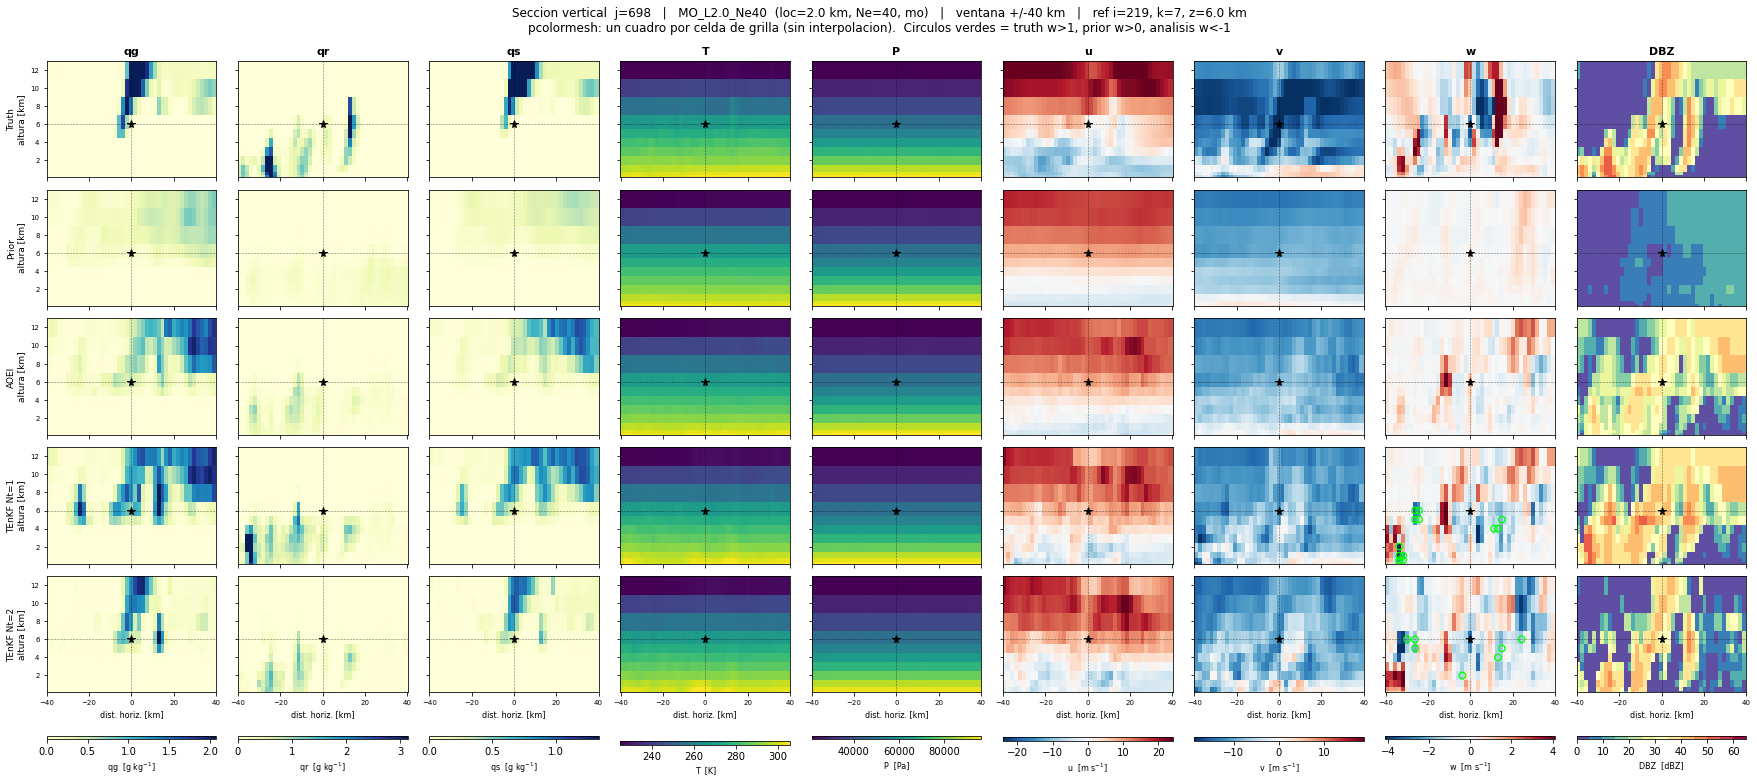

severe points inside the window (circled green):
   row           all cells   at obs pts
   AOEI                  0            0
   TEnKF Nt=1           13            5
   TEnKF Nt=2            7            2

observed cells inside the window: 242 of 473 (51%)


In [8]:
# ===========================================================================
# FIGURE 1 -- one scenario: 5 rows (Truth / Prior / AOEI / TEnKF1 / TEnKF2) x 9 variables
# ===========================================================================
R = rows(SCEN_MAIN)
s = SCEN[SCEN_MAIN]

fig, ax = plt.subplots(len(ROW_LABELS), len(COLS), figsize=(2.7 * len(COLS), 2.15 * len(ROW_LABELS)),
                       sharex=True, sharey=True, constrained_layout=True)

n_sev = {}
for c, v in enumerate(COLS):
    Fs = [cut(disp(v, R[r][v])) for r in ROW_LABELS]
    kw = scales(Fs, v)
    for r, lab in enumerate(ROW_LABELS):
        im = panel(ax[r, c], Fs[r], **kw)
        decorate(ax[r, c])
        if r >= 2:
            overlay_obs(ax[r, c])
            if v == 'w':
                n_sev[lab] = overlay_severe(ax[r, c], sev_mask(R, lab))
    fig.colorbar(im, ax=ax[:, c].tolist(), orientation='horizontal',
                 fraction=0.030, pad=0.015, aspect=22).set_label(f'{v}  [{UNITS[v]}]', fontsize=8)
    ax[0, c].set_title(v, fontsize=11, weight='bold')

for r, lab in enumerate(ROW_LABELS):
    ax[r, 0].set_ylabel(f'{lab}\naltura [km]', fontsize=9)
for c in range(len(COLS)):
    ax[-1, c].set_xlabel('dist. horiz. [km]', fontsize=8)
for a in ax.ravel():
    a.tick_params(labelsize=7)

fig.suptitle(f'Seccion vertical  j={J0}   |   {SCEN_MAIN}  '
             f'(loc={s["loc"]} km, Ne={s["ne"]}, {s["kind"]})   |   ventana +/-{WIN_KM:.0f} km   '
             f'|   ref i={i_c}, k={K_C}, z={z0:.1f} km\n'
             f'pcolormesh: un cuadro por celda de grilla (sin interpolacion).  '
             f'Circulos verdes = truth w>1, prior w>0, analisis w<-1', fontsize=12)
plt.show()

print('severe points inside the window (circled green):')
print(f'   {"row":12s} {"all cells":>10s} {"at obs pts":>12s}')
for lab in [l for l, _ in ANALYSES]:
    a_, o_ = n_sev.get(lab, (0, 0))
    print(f'   {lab:12s} {a_:10d} {o_:12d}')
print(f'\nobserved cells inside the window: {int(OBSJ[xi].sum())} of {OBSJ[xi].size} '
      f'({OBSJ[xi].mean():.0%})')
if s['loc'] < 1.0:
    print('loc=0.1 km -> only the observed cells were updated: the analysis rows are a comb.')

## Reading Figure 1

* **The colour scale is shared down each column**, so a row-to-row change is a real change in the
  field, not a rescaling. Between columns nothing is comparable — each has its own scale and units.
* **`T` and `P` are stripes.** That is not a bug: their vertical stratification is 43× and 1080×
  larger than the analysis increment, and this notebook is configured to plot raw values. Figure 3
  removes the prior and makes both readable. Setting `ANOM_VARS = ('T','P','u','v')` in the config
  cell does the same for this figure.
* **Green circles** mark the S7 pathology — the truth has an updraft (`w > 1`), the prior has an
  updraft (`w > 0`), and the analysis produces a downdraft (`w < −1`). Compare the `AOEI` row
  against `TEnKF Nt=1`: AOEI should have far fewer, or none.
* **The black star is not necessarily an observed cell.** It marks either the pinned column or the
  prior reflectivity maximum along `(j, k_c)`. On the `j=272` storm slice that maximum falls on
  `i=235`, an *odd* column — and `stride=2` observes only even ones, so the strongest echo in the
  prior was never assimilated. (That is the same `i=235` the old `SingleObs_CrossSection.ipynb`
  hardcoded as an *observation* index, which is why its analysis panel showed untouched prior where
  it claimed to show an analysis.)
* If `SCEN_MAIN` has `loc=0.1`, the analysis rows are a **comb**: only even `i`-columns were
  observed and each observation updates its own cell alone. Set `SHOW_OBS = True` to see exactly
  which cells were touched.

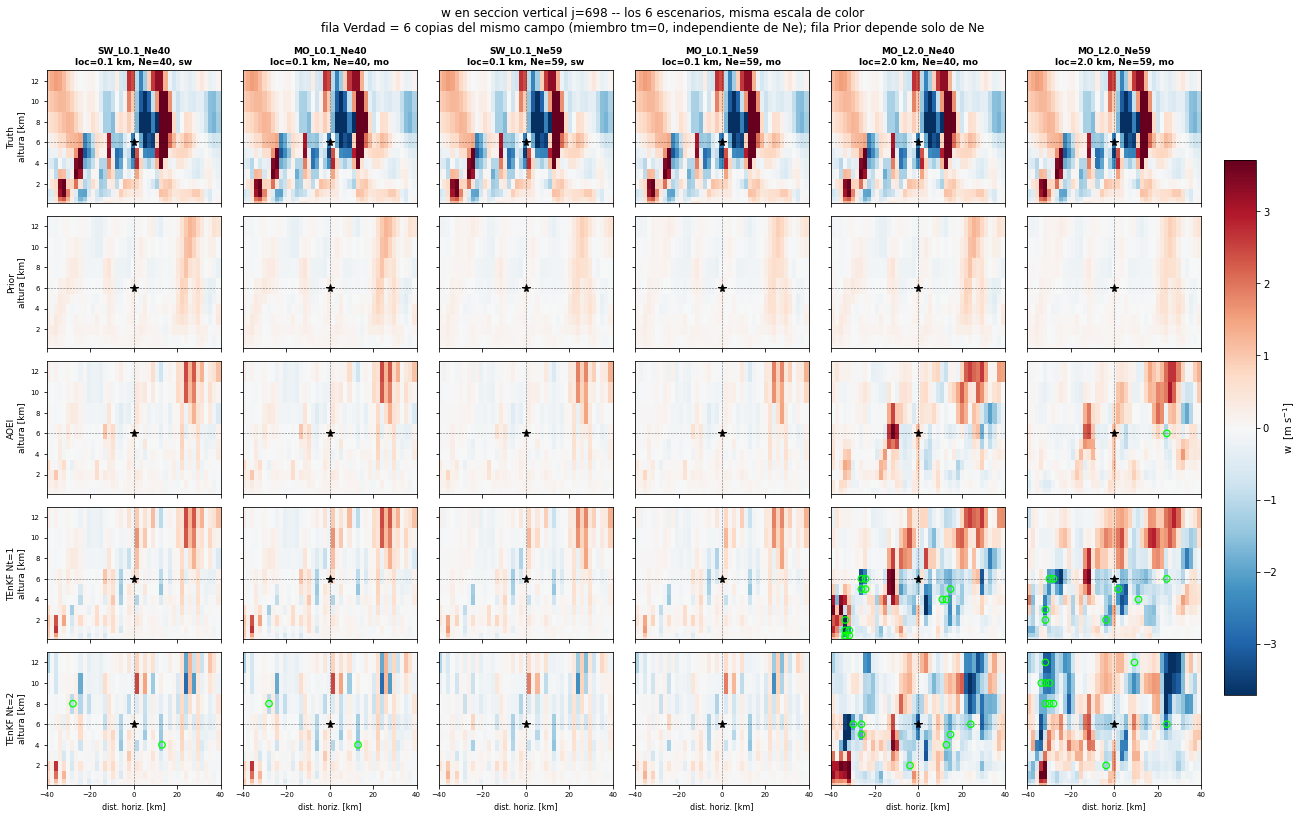

Truth row identical across all 6 columns : True
Prior row identical across Ne=40 columns : True   (3 columns)
Prior row identical across Ne=59 columns : True   (3 columns)

severe points on j=698 inside the +/-40 km window -- "all cells" (and "at observed cells"):
       SW_L0.1_Ne40     MO_L0.1_Ne40     SW_L0.1_Ne59     MO_L0.1_Ne59     MO_L2.0_Ne40     MO_L2.0_Ne59
   AOEI             0 (  0)       0 (  0)       0 (  0)       0 (  0)       0 (  0)       1 (  1)
   TEnKF Nt=1       0 (  0)       0 (  0)       0 (  0)       0 (  0)      13 (  5)       8 (  5)
   TEnKF Nt=2       2 (  2)       2 (  2)       0 (  0)       0 (  0)       7 (  2)      10 (  6)

Domain-wide, at OBSERVED cells (the definition S7 uses), TEnKF Nt=1 gives
   loc=0.1 -> 18 (Ne=40) / 22 (Ne=59)      loc=2.0 -> 125 (Ne=40) / 198 (Ne=59)
Over ALL cells the same runs give 710 (Ne=40) / 845 (Ne=59) at loc=2.0.


In [9]:
# ===========================================================================
# FIGURE 2 -- one variable, the same 5 rows, one column per scenario
# ===========================================================================
NAMES = list(SCEN)                       # ordered: each sweep sits beside its loc=0.1 twin
ALL = {n: rows(n) for n in NAMES}        # ~40 s on a cold cache

Fs = {(n, r): cut(disp(VAR_CMP, ALL[n][r][VAR_CMP])) for n in NAMES for r in ROW_LABELS}
kw = scales(list(Fs.values()), VAR_CMP)  # ONE scale for all 30 panels

fig, ax = plt.subplots(len(ROW_LABELS), len(NAMES), figsize=(3.0 * len(NAMES), 2.25 * len(ROW_LABELS)),
                       sharex=True, sharey=True, constrained_layout=True)

sev_tab = {}
for c, n in enumerate(NAMES):
    sc = SCEN[n]
    for r, lab in enumerate(ROW_LABELS):
        im = panel(ax[r, c], Fs[(n, lab)], **kw)
        decorate(ax[r, c])
        if r >= 2:
            overlay_obs(ax[r, c])
            if VAR_CMP == 'w':
                sev_tab[(n, lab)] = overlay_severe(ax[r, c], sev_mask(ALL[n], lab))
    ax[0, c].set_title(f'{n}\nloc={sc["loc"]} km, Ne={sc["ne"]}, {sc["kind"]}', fontsize=9, weight='bold')

for r, lab in enumerate(ROW_LABELS):
    ax[r, 0].set_ylabel(f'{lab}\naltura [km]', fontsize=9)
for c in range(len(NAMES)):
    ax[-1, c].set_xlabel('dist. horiz. [km]', fontsize=8)
for a in ax.ravel():
    a.tick_params(labelsize=7)

fig.colorbar(im, ax=ax.ravel().tolist(), orientation='vertical', shrink=0.75,
             fraction=0.015, pad=0.01).set_label(f'{VAR_CMP}  [{UNITS[VAR_CMP]}]', fontsize=10)
fig.suptitle(f'{VAR_CMP} en seccion vertical j={J0} -- los 6 escenarios, misma escala de color\n'
             f'fila Verdad = 6 copias del mismo campo (miembro tm=0, independiente de Ne); '
             f'fila Prior depende solo de Ne', fontsize=12)
plt.show()

# The Truth row is the same field six times and Prior depends only on Ne: built-in visual assertions.
_t = [ALL[n]['Truth'][VAR_CMP] for n in NAMES]
print(f'Truth row identical across all 6 columns : '
      f'{all(np.array_equal(x, _t[0], equal_nan=True) for x in _t)}')
for ne in (40, 59):
    g = [ALL[n]['Prior'][VAR_CMP] for n in NAMES if SCEN[n]['ne'] == ne]
    print(f'Prior row identical across Ne={ne} columns : '
          f'{all(np.array_equal(x, g[0], equal_nan=True) for x in g)}   ({len(g)} columns)')

if VAR_CMP == 'w':
    print(f'\nsevere points on j={J0} inside the +/-{WIN_KM:.0f} km window '
          f'-- "all cells" (and "at observed cells"):')
    print('   ' + ' '.join(f'{n:>16s}' for n in NAMES))
    for lab in [l for l, _ in ANALYSES]:
        cells = ' '.join(f'{sev_tab[(n, lab)][0]:>7d} ({sev_tab[(n, lab)][1]:>3d})' for n in NAMES)
        print(f'   {lab:11s}' + cells)
    print(f'\nDomain-wide, at OBSERVED cells (the definition S7 uses), TEnKF Nt=1 gives')
    print(f'   loc=0.1 -> 18 (Ne=40) / 22 (Ne=59)      loc=2.0 -> 125 (Ne=40) / 198 (Ne=59)')
    print(f'Over ALL cells the same runs give 710 (Ne=40) / 845 (Ne=59) at loc=2.0.')

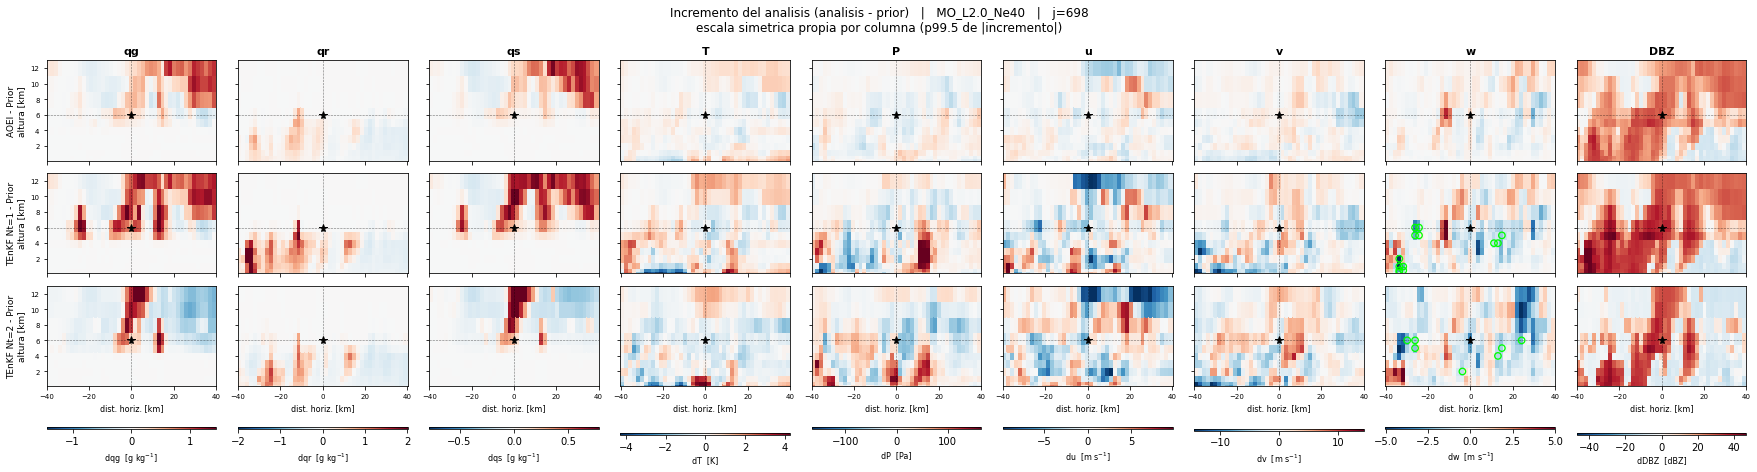

MO_L2.0_Ne40, j=698: p99 of |increment| vs the truth level-mean span, in RAW units
   var      p99|inc|   levmean span     ratio
   qg      0.0005767       3.86e-05       0.1  kg/kg
   qr      0.0004343       3.68e-05       0.1  kg/kg
   qs      0.0002271      3.918e-05       0.2  kg/kg
   T           2.041          80.68      39.5  K   <- stratification swamps the increment
   P           63.16      7.378e+04    1168.2  Pa   <- stratification swamps the increment
   u           4.503          30.74       6.8  m/s
   v           5.508          8.529       1.5  m/s
   w           1.712        0.08221       0.0  m/s
   DBZ         32.67           53.9       1.7  dBZ


In [10]:
# ===========================================================================
# FIGURE 3 -- increments (analysis - prior).  This is where T and P become readable.
# ===========================================================================
LABS = [l for l, _ in ANALYSES]
R = rows(SCEN_MAIN)          # free: every slice it needs is already in the _SL cache

fig, ax = plt.subplots(len(LABS), len(COLS), figsize=(2.7 * len(COLS), 2.15 * len(LABS)),
                       sharex=True, sharey=True, constrained_layout=True)

for c, v in enumerate(COLS):
    Ds = [cut(disp(v, R[l][v]) - disp(v, R['Prior'][v])) for l in LABS]
    kw = sym_scale(Ds)
    for r, lab in enumerate(LABS):
        im = panel(ax[r, c], Ds[r], **kw)
        decorate(ax[r, c])
        overlay_obs(ax[r, c])
        if v == 'w':
            overlay_severe(ax[r, c], sev_mask(R, lab))
    fig.colorbar(im, ax=ax[:, c].tolist(), orientation='horizontal',
                 fraction=0.045, pad=0.02, aspect=22).set_label(f'd{v}  [{UNITS[v]}]', fontsize=8)
    ax[0, c].set_title(v, fontsize=11, weight='bold')

for r, lab in enumerate(LABS):
    ax[r, 0].set_ylabel(f'{lab} - Prior\naltura [km]', fontsize=9)
for c in range(len(COLS)):
    ax[-1, c].set_xlabel('dist. horiz. [km]', fontsize=8)
for a in ax.ravel():
    a.tick_params(labelsize=7)

fig.suptitle(f'Incremento del analisis (analisis - prior)   |   {SCEN_MAIN}   |   j={J0}\n'
             f'escala simetrica propia por columna (p99.5 de |incremento|)', fontsize=12)
plt.show()

print(f'{SCEN_MAIN}, j={J0}: p99 of |increment| vs the truth level-mean span, in RAW units')
print(f'   {"var":4s} {"p99|inc|":>12s} {"levmean span":>14s} {"ratio":>9s}')
for v in COLS:
    d = np.abs(np.concatenate([(R[l][v] - R['Prior'][v]).ravel() for l in LABS]))
    d = d[np.isfinite(d)]
    p99 = float(np.percentile(d, 99)) if d.size else 0.0
    if v == 'DBZ':
        span = float(np.nanmax(R['Truth'][v]) - np.nanmin(R['Truth'][v]))
    else:
        lm = np.nanmean(R['Truth'][v], axis=0)
        span = float(np.nanmax(lm) - np.nanmin(lm))
    ratio = span / p99 if p99 > 0 else float('inf')
    flag = '   <- stratification swamps the increment' if ratio > 20 else ''
    print(f'   {v:4s} {p99:12.4g} {span:14.4g} {ratio:9.1f}  {RAW_UNITS[v]}{flag}')

## What to look for

**A physically wrong update looks like this:** in the `w` column the truth has a coherent updraft
core, the prior has a weak updraft in the same place, and the analysis paints a strong *downdraft*
there (green circles). Figure 3 shows the mechanism directly — a large negative `dw` exactly where
the prior reflectivity was far below the observation.

That is not a coding bug. The single-observation LETKF mean update collapses exactly to

$$\Delta w = \mathrm{dep}_b \cdot \frac{\mathrm{cov}(w, h)}{\mathrm{var}(h) + R}$$

and at the severe points `cov(w, dBZ) < 0` in 100% of cases while `dep_b > 0` in 100% of cases.
Only ~4 of 59 prior members carry any echo, and they contribute 95% of that covariance — so the
gain is a 4-sample statistic multiplied by a `+40 dBZ` innovation. The truth lies outside the prior
ensemble's range at 83% of those points: the ensemble simply cannot reach it, and the linear update
faithfully follows the (badly estimated) covariance in the wrong direction.

**Things worth checking visually:**

* `AOEI` should clean the `w` column up almost completely — it inflates `R̃ = max(R₀, dep_b² − σ²_f)`
  to ≈1487 against `R₀ = 5`, shrinking the gain ~26×. Domain-wide it drops 710 → 177 severe cells.
* `TEnKF Nt=2` is *worse* than `Nt=1` domain-wide (710 → 1536), not better. Tempering aggravates the
  flip, with an odd/even sawtooth across `ntemp` (`Nt=3` → 1118). A single window is too small to
  show that reliably — trust the domain-wide numbers printed by the `SEVERE SCAN` cell.
* The two `loc=0.1` sweep columns must be visually indistinguishable from their multi_obs twins.
  The verification cell already asserts this numerically for `k ≥ 2`; the eye is the backup.
* Larger `Ne` gives **more** severe points, not fewer (`125 → 198` at observed cells, `710 → 845`
  over all cells). Adding members to a storm-free prior raises the chance that some member carries
  echo at a clear-air cell, which manufactures a spurious covariance for the huge innovation to
  multiply.

**Two counting conventions, never mix them.** `S7` counts severe points at *observed* cells; the
whole-domain count is ~5.7× larger because `loc=2.0` updates far more cells than it observes.

| `MO_L2.0_Ne40`, domain-wide | all cells | at obs cells |
|---|---|---|
| AOEI | 177 | 19 |
| TEnKF Nt=1 | 710 | 125 |
| TEnKF Nt=2 | 1536 | 357 |
| TEnKF Nt=3 | 1118 | 252 |

**Caveat carried from S7:** Ne=40 (members 002–041) is a strict subset of Ne=59 (002–060), so
ensemble *size* and ensemble *composition* remain confounded. Separating them needs a run with
`prior_start: 19, prior_size: 40`.

Mechanism, closed-form validation and the full severe-point matrix: `S7_SignFlip_Mechanism.ipynb`.